# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">MatrixBrekzie 90°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 147
Average Fx in the averaging interval [1045:1192]: 4.438513412605338
Average Fz in the averaging interval [1045:1192]: 0.45171139256483844
Maximum Fz in the plotting interval [1045:None]: 1.14527587890625 at timestep 1189
Time step where Fx drops below 1: 1196


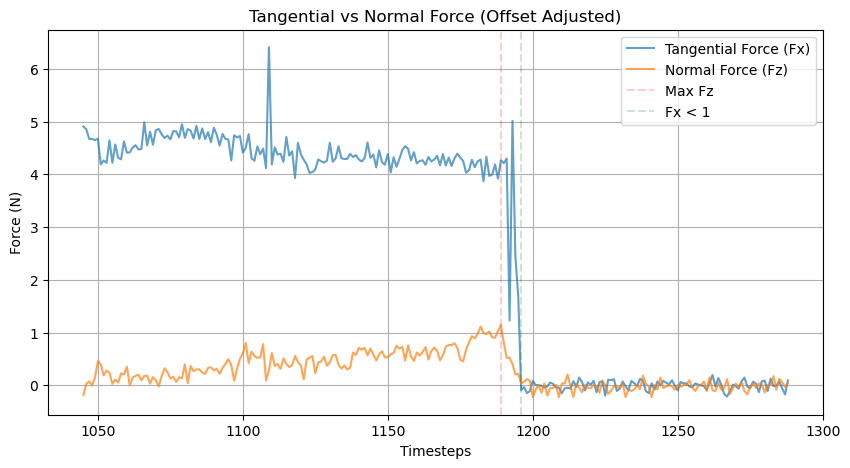

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_90_5N//log_202405231737.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=1045, cut_2=None, avg_end=1192, offset_position='end', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 122
Average Fx in the averaging interval [775:897]: 5.1742900548736905
Average Fz in the averaging interval [775:897]: 0.1625019344475751
Maximum Fz in the plotting interval [775:950]: 0.4499104817708333 at timestep 889
Time step where Fx drops below 1: 897


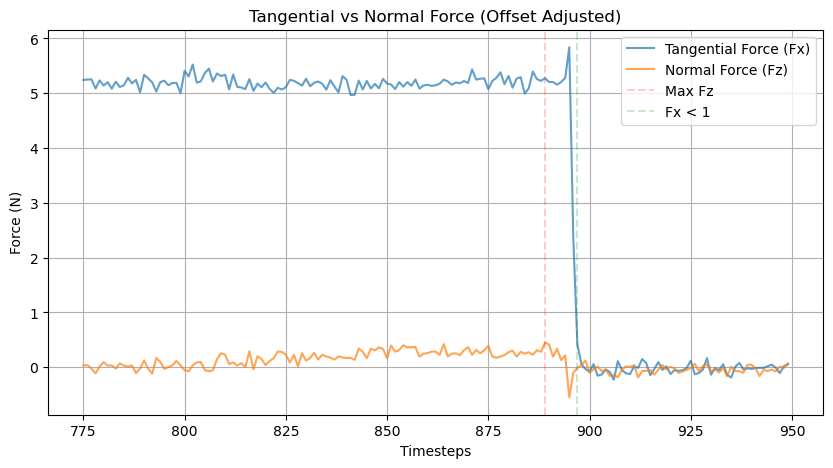

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_90_5N//log_202405231739.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=775, cut_2=950, avg_end=897, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 221
Average Fx in the averaging interval [1132:1353]: 4.20665048510061
Average Fz in the averaging interval [1132:1353]: 0.48392413155165914
Maximum Fz in the plotting interval [1132:None]: 0.9907918294270833 at timestep 1305
Time step where Fx drops below 1: 1353


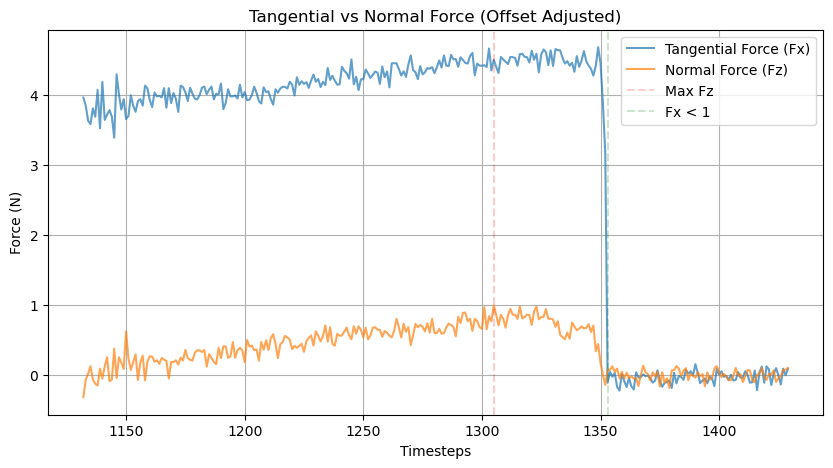

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_90_5N//log_202405231740.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=1132, cut_2=None, avg_end=1353, offset_position='end', offset_length=15)

<font size="6">Test 4: (failed)</font>

Average Fx in the averaging interval [None:None]: 2.7952239846342013
Average Fz in the averaging interval [None:None]: -1.363755386055014
Maximum Fz in the plotting interval [None:None]: 0.2591837565104167 at timestep 982
Time step where Fx drops below 1: 0


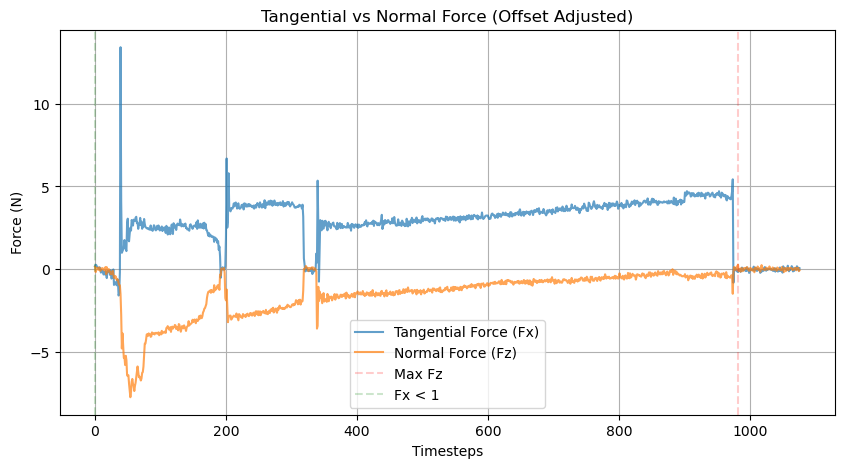

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_90_5N//log_202405231741.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 632
Average Fx in the averaging interval [1120:1752]: 5.478302598150471
Average Fz in the averaging interval [1120:1752]: 1.380255146268048
Maximum Fz in the plotting interval [1120:None]: 2.88782958984375 at timestep 1734
Time step where Fx drops below 1: 1752


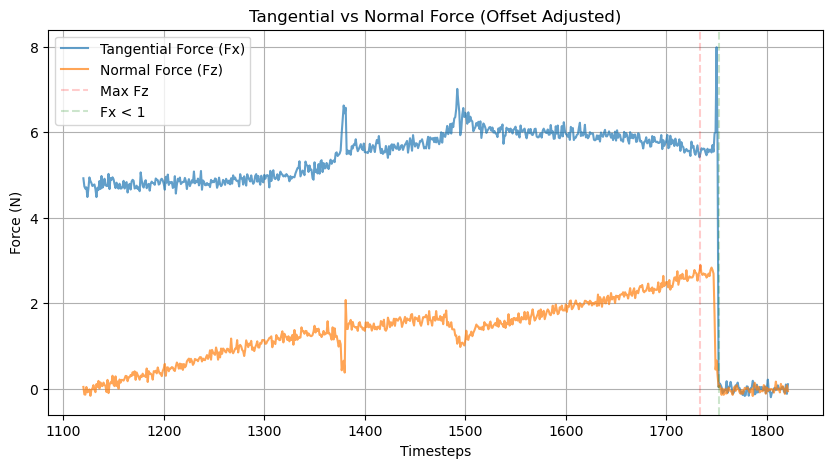

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_90_5N//log_202405231742.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=1120, cut_2=None, avg_end=1752, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 561
Average Fx in the averaging interval [1040:1601]: 5.890623351894385
Average Fz in the averaging interval [1040:1601]: 0.818349996692569
Maximum Fz in the plotting interval [1040:None]: 2.218025716145833 at timestep 1592
Time step where Fx drops below 1: 1601


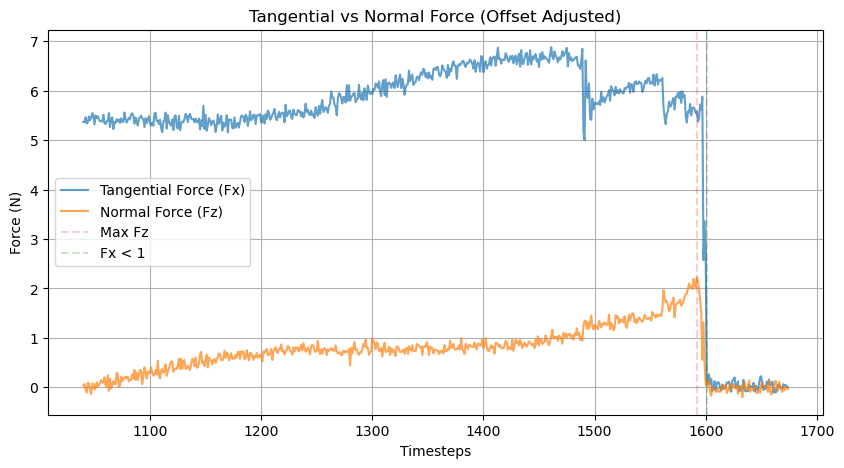

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_90_5N//log_202405231744.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=1040, cut_2=None, avg_end=1601, offset_position='end', offset_length=15)

<font size="6">Test 7: (failed)</font>

Average Fx in the averaging interval [None:None]: 3.6537554551211158
Average Fz in the averaging interval [None:None]: -2.062790822630935
Maximum Fz in the plotting interval [None:None]: 0.14363606770833334 at timestep 986
Time step where Fx drops below 1: 0


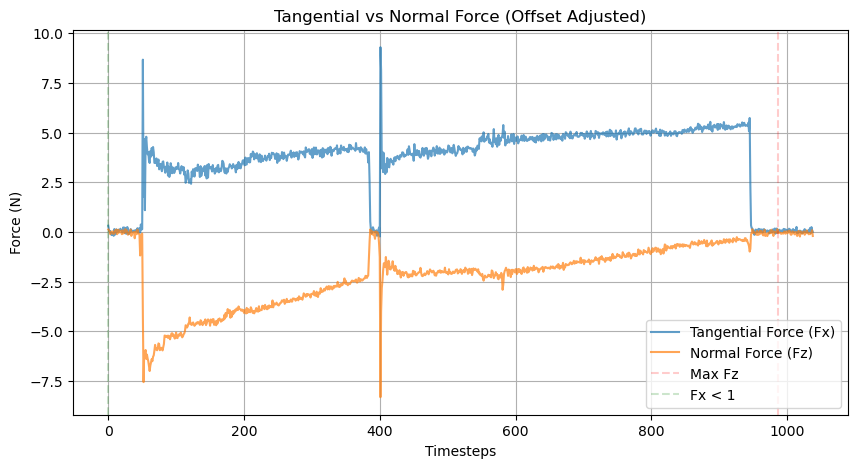

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_90_5N//log_202405231745.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 8: (whole diagram!!!)</font>

Length from cut_1 to avg_end: 1170
Average Fx in the averaging interval [300:1470]: 5.163671623539721
Average Fz in the averaging interval [300:1470]: 0.4252591124966614
Maximum Fz in the plotting interval [300:1470]: 2.13492431640625 at timestep 913
Time step where Fx drops below 1: 912


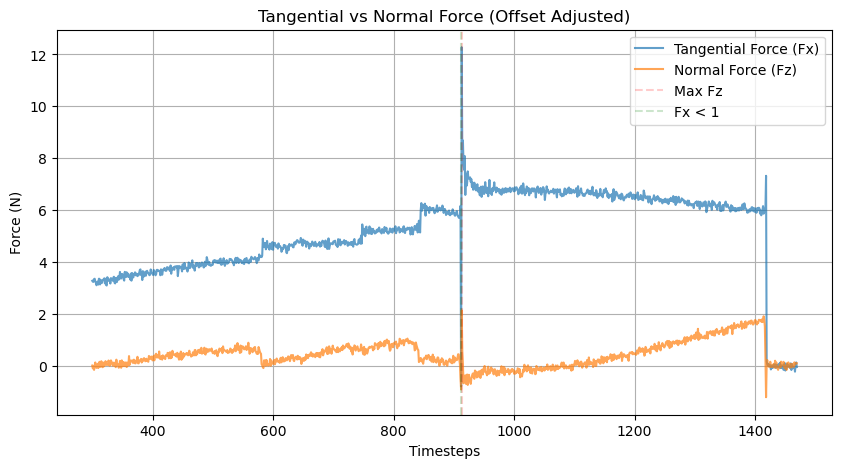

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_90_5N//log_202405231747.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=300, cut_2=1470, avg_end=None, offset_position='end', offset_length=15)

<font size="6">Test 8a: (worked)</font>

Length from cut_1 to avg_end: 612
Average Fx in the averaging interval [300:912]: 4.469906475653056
Average Fz in the averaging interval [300:912]: 0.4273030598958334
Maximum Fz in the plotting interval [300:913]: 1.04617919921875 at timestep 823
Time step where Fx drops below 1: 912


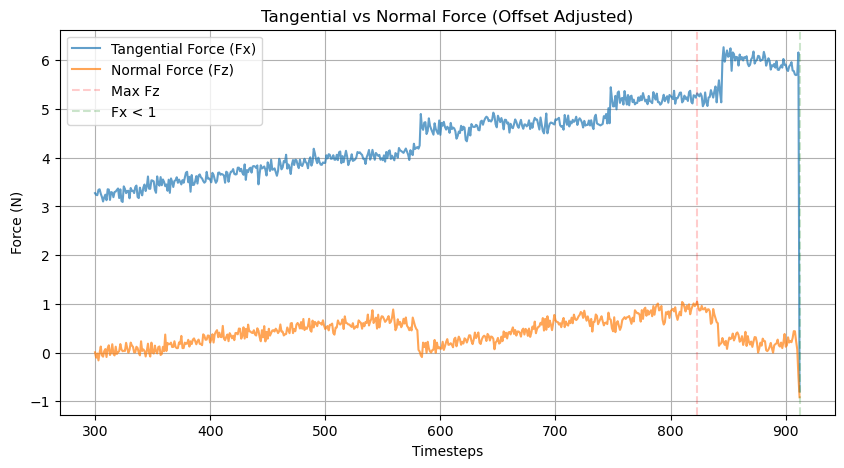

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_90_5N//log_202405231747.csv"
df = pd.read_csv(data)
test_8a, end_8a = plot_forces(df, cut_1=300, cut_2=913, avg_end=912, offset_position='end', offset_length=15)

<font size="6">Test 8b: (worked)</font>

Length from cut_1 to avg_end: 322
Average Fx in the averaging interval [1097:1419]: 6.361300085592961
Average Fz in the averaging interval [1097:1419]: 0.8351666373495731
Maximum Fz in the plotting interval [1097:None]: 1.90604248046875 at timestep 1414
Time step where Fx drops below 1: 1419


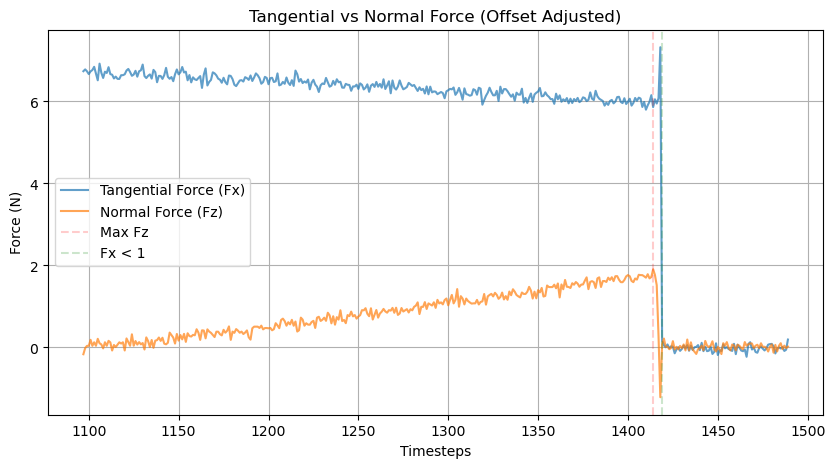

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_90_5N//log_202405231747.csv"
df = pd.read_csv(data)
test_8b, end_8b = plot_forces(df, cut_1=1097, cut_2=None, avg_end=1419, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 348
Average Fx in the averaging interval [530:878]: 5.689687007049034
Average Fz in the averaging interval [530:878]: 0.38015519065418457
Maximum Fz in the plotting interval [530:879]: 0.97265625 at timestep 836
Time step where Fx drops below 1: nan


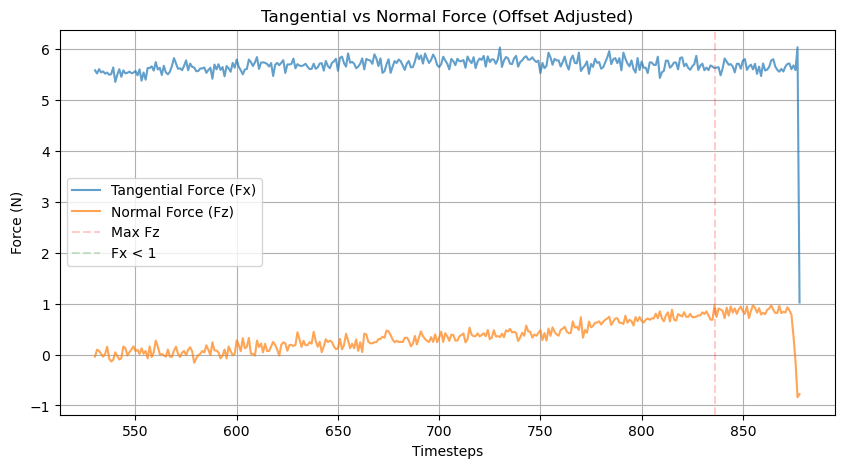

In [13]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_90_5N//log_202405231749.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=530, cut_2=879, avg_end=878, offset_position='beginning', offset_length=15)

<font size="6">Test 10: (failed)</font>

Average Fx in the averaging interval [None:None]: 0.9433350461505509
Average Fz in the averaging interval [None:None]: -0.3292602092409326
Maximum Fz in the plotting interval [None:None]: 0.22886555989583335 at timestep 551
Time step where Fx drops below 1: 0


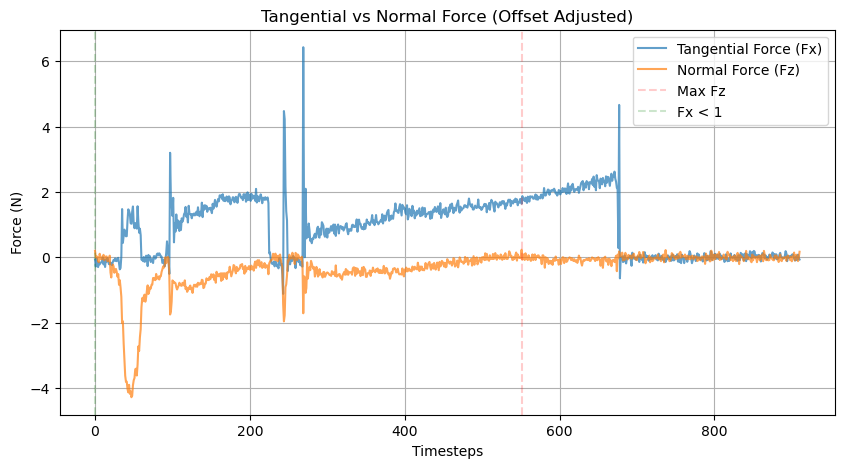

In [14]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_90_5N//log_202405231750.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='end', offset_length=15)

In [15]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [19]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//90//MatrixBrekzie_90_stats.csv", index=False)

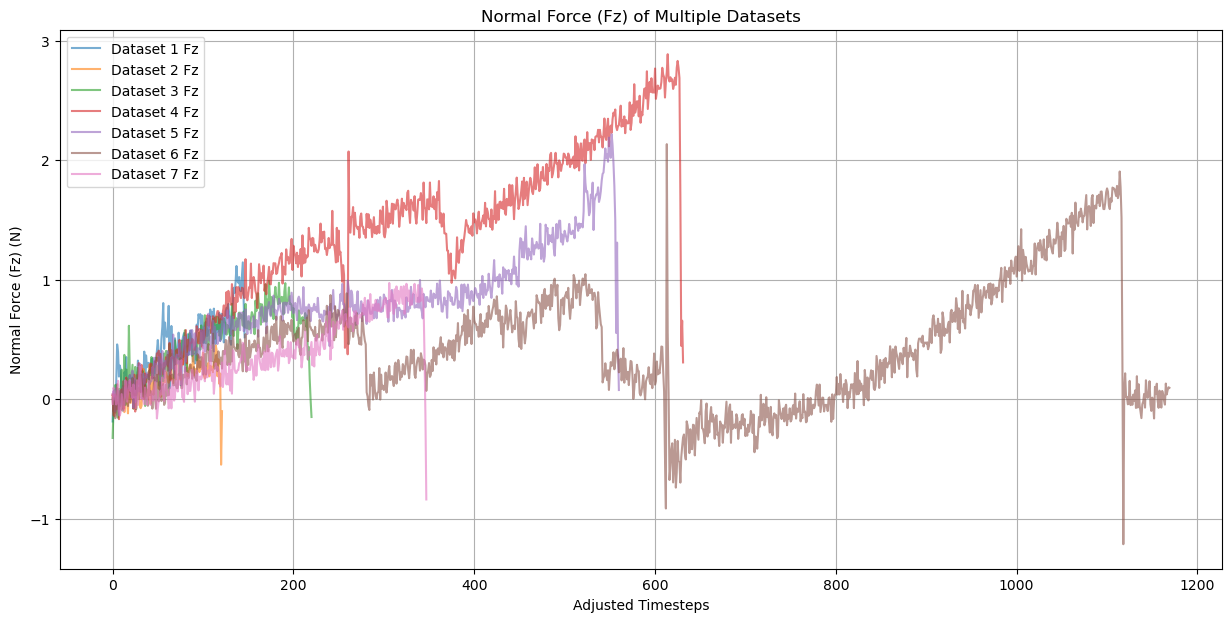

Average of maximum Fz forces: 1.5427734375
Standard deviation of maximum Fz forces: 0.8104544940420214
Average of average Fz forces: 0.5860224149536479
Standard deviation of average Fz forces: 0.37049021537152727
Average of average Fx forces: 5.148819790459036
Standard deviation of average Fx forces: 0.5787247374305781


In [20]:
tests = [test_1, test_2, test_3, test_5, test_6, test_8, test_9]
ends = [end_1, end_2, end_3, end_5, end_6, end_8, end_9]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [21]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//90//MatrixBrekzie_90"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)